# Recreation of Figure 2D from Tolooshams et al.
## BIPN 162 Final Project

By Emily McClung, Naomi Ortega, and Isabel Rodriguez

This notebook contains the code for recreating a visualization from the paper "Interpretable deep learning for deconvolutional analysis of neural signals" by Tolooshams, B., Matias, S., Wu, H., Temereanca, S., Uchida, N., Murthy, V. N., Masset, P., & Ba, D (2025) https://doi.org/10.1016/j.neuron.2025.02.006. We recreate Figure 2D from their dopamine spiking experiment, which visualizes how the data analysis method they introduce, called Deconvolutional Unrolled Neural Learning (DUNL), learns interpretable event-related kernels capturing salience and value signals from dopamine neurons.
We recreate their resuslts using their experiment data zip
`dopamine-spiking-eshel-uchida.zip` that is available here: https://data.mendeley.com/datasets/rzfyr2886h/1 

## Setup
Import necessary packages and load the GitHub Repository containing the DUNL code.

In [4]:
#import necessary packages
import numpy as np
import torch
import sklearn
import h5py
import configmypy
import matplotlib.pyplot as plt

In [39]:
#Clone the DUNL algorithm GitHub Repository
!git clone https://github.com/btolooshams/dunl-compneuro.git

fatal: destination path 'dunl-compneuro' already exists and is not an empty directory.


In [55]:
#Import the DUNL code
import sys
sys.path.append("dunl-compneuro")
import dunl

In [41]:
!ls dunl-compneuro/dunl

__pycache__	     preprocess_scripts
boardfunc.py	     train_fiber_loop_acrossneurons.py
datasetloader.py     train_independentkernels_acrossneurons.py
lossfunc.py	     train_sharekernels_acrossneurons.py
model.py	     train_sharekernels_acrossneurons_groupneuralfirings.py
postprocess_scripts  utils.py


## Data Wrangling

In [54]:
#unzip the data from the zip file it comes as
!unzip dopamine-spiking-eshel-uchida.zip

Archive:  dopamine-spiking-eshel-uchida.zip
   creating: dopamine-spiking-eshel-uchida/
  inflating: dopamine-spiking-eshel-uchida/03_05_TT8_1_CommonFormat_verified_25msbinres_general_format_processed_kernellength24_kernelnum3_trainready.pt  
  inflating: dopamine-spiking-eshel-uchida/D_05-01_15-31-27_TT6_1_Common_25msbinres_general_format_processed_kernellength24_kernelnum3_trainready.pt  
  inflating: dopamine-spiking-eshel-uchida/10_26_TT7_2_CommonFormat_verified_25msbinres_general_format_processed_kernellength24_kernelnum3_trainready.pt  
  inflating: dopamine-spiking-eshel-uchida/D_05-14_14-16-28_TT3_1_Common_25msbinres_general_format_processed_kernellength24_kernelnum3_trainready.pt  
  inflating: dopamine-spiking-eshel-uchida/02_13_TT2_1_CommonFormat_verified_25msbinres_general_format_processed_kernellength24_kernelnum3_trainready.pt  
  inflating: dopamine-spiking-eshel-uchida/O_05-06_14-45-15_TT8_2_Common_25msbinres_general_format_processed_kernellength24_kernelnum3_trainready

Load in the data file for one neuron to see the size and contents.

In [70]:
#load one part of the data to look at what is contained in it
data = torch.load("dunl-compneuro/data/dopamine-spiking-eshel-uchida/02_09_TT2_1_CommonFormat_verified_25msbinres_general_format_processed_kernellength24_kernelnum3_trainready.pt")
print(data.keys())

#understanding the size of the raw data
print(data['raster'].size()) #This one file contains 150 trials of spike data from 1 neuron, and each trial contains 3100 time bins. (3100 bins X 25 ms = 77.5 seconds per trial) 

#understanding the size of the training data after preprocessing
print(data['y'].size()) # For each neuron, DUNL is trained on 124 time bins of 25 ms each, for 3.1 seconds per trial. There is a 3.1 second window containing the cue and reward events DUNL evaluates

dict_keys(['raster', 'time_org_resolution', 'time_bin_resolution', 'y', 'x', 'a', 'type'])
torch.Size([150, 1, 3100])
torch.Size([150, 1, 124])


In [72]:
#Tolooshams et al. used a sample of 40 neurons. Check how this dataset compares
files = os.listdir("dunl-compneuro/data/dopamine-spiking-eshel-uchida")
pt_files = [f for f in files if f.endswith(".pt")]
print(len(pt_files)) #There are 39 neuron files.

for f in pt_files[:40]:
    d = torch.load(f"dunl-compneuro/data/dopamine-spiking-eshel-uchida/{f}")
    print(d['raster'].shape) #The samples differ in how many trials were recorded in the session. 
                            # Since DUNL treats each neuron independently and the kernels are shared across neurons, this is no problem. 
                            # Importantly, the time dimension is consistent.

39
torch.Size([250, 1, 3100])
torch.Size([284, 1, 3100])
torch.Size([135, 1, 3100])
torch.Size([270, 1, 3100])
torch.Size([198, 1, 3100])
torch.Size([303, 1, 3100])
torch.Size([303, 1, 3100])
torch.Size([179, 1, 3100])
torch.Size([271, 1, 3100])
torch.Size([187, 1, 3100])
torch.Size([264, 1, 3100])
torch.Size([228, 1, 3100])
torch.Size([228, 1, 3100])
torch.Size([146, 1, 3100])
torch.Size([193, 1, 3100])
torch.Size([221, 1, 3100])
torch.Size([187, 1, 3100])
torch.Size([213, 1, 3100])
torch.Size([162, 1, 3100])
torch.Size([198, 1, 3100])
torch.Size([213, 1, 3100])
torch.Size([212, 1, 3100])
torch.Size([193, 1, 3100])
torch.Size([122, 1, 3100])
torch.Size([150, 1, 3100])
torch.Size([207, 1, 3100])
torch.Size([205, 1, 3100])
torch.Size([152, 1, 3100])
torch.Size([291, 1, 3100])
torch.Size([150, 1, 3100])
torch.Size([188, 1, 3100])
torch.Size([281, 1, 3100])
torch.Size([281, 1, 3100])
torch.Size([281, 1, 3100])
torch.Size([291, 1, 3100])
torch.Size([168, 1, 3100])
torch.Size([250, 1, 3100]

Inspecting the size of the contents of the data indicates that this data contains only 39 neurons, whereas Tolooshams et al. used 40. This will not affect the analysis, since DUNL learns shared kernels across neurons.

Understanding the keys contained in the data:
* Raster = Original spike train (DUNL does not train directly on these
* time_org_resolution = Original time resolution of the spike recording (time spacing of the raster spikes)
* time_bin_resolution = the time resolution used for binning the spikes. here, spikes occuring within 25 ms of each other are grouped into the same bin
* y = Binned spike counts
* x = Matrix of event timing (rewards)
* a = Restricts the model to activities within certain event windows to improve interpretability
* type = trial type/ reward condition

The data from the experiment in the paper are already in training format, such as the raw spike data being binned into 25 ms bins. The daata are ready to be used with DUNL. No further preprocessing is necessary.

In [14]:
#Move data into folder the algorithm expects
!mkdir -p dunl-compneuro/data
!mv dopamine-spiking-eshel-uchida dunl-compneuro/data/

Changes made to configurations in the dunl-compneuro repo:
1. In `config/dopamine_spiking_eshel_uchida_code122_kernel011_config.yaml/`
changed **from** `data_folder:  "../data/dopamine-spiking-eshel-uchida"`
**to** `data_folder: "dunl-compneuro/data/dopamine-spiking-eshel-uchida"`

2. In `dunl/train_sharekernels_acrossneurons.py` inside `init_params()`
 **commented out** `default="./dopamine_calcium_saramatias_uchida_config.yaml"`
and **uncommented** `default="./dopamine_spiking_eshel_uchida_code122_kernel011_config.yaml"` because we are running the dopamine spiking experiment on the dopamine spiking data, but this code contains configurations for the other experiments from their paper too. Later, we will use the calcium configuration when we apply DUNL to fiber photometry data.




## Running DUNL Analysis

In [63]:
##Run DUNL training to obtain learned event kernels from the data

In [20]:
!python dunl-compneuro/dunl/train_sharekernels_acrossneurons.py

Train DUNL on neural data.
device is cuda:0
init parameters.
Exp: dopaminespiking_25msbin_kernellength24_kernelnum3_code122_kernel011
create board.
create dataset and dataloader.
There 39 dataset in the folder.
dunl-compneuro/data/dopamine-spiking-eshel-uchida/10_26_TT6_1_CommonFormat_verified_25msbinres_general_format_processed_kernellength24_kernelnum3_trainready.pt
x is shared among neurons. It is a function of trials, and number of kernels!
dunl-compneuro/data/dopamine-spiking-eshel-uchida/D_04-29_16-11-32_TT6_4_Common_25msbinres_general_format_processed_kernellength24_kernelnum3_trainready.pt
x is shared among neurons. It is a function of trials, and number of kernels!
dunl-compneuro/data/dopamine-spiking-eshel-uchida/02_13_TT2_1_CommonFormat_verified_25msbinres_general_format_processed_kernellength24_kernelnum3_trainready.pt
x is shared among neurons. It is a function of trials, and number of kernels!
dunl-compneuro/data/dopamine-spiking-eshel-uchida/O_05-06_14-45-15_TT8_2_Common

Training DUNL is complete. Now we will inspect the resulting learned kernels.

In [2]:
import sys, os

sys.path.append(os.path.abspath("dunl-compneuro/dunl"))

import model

In [5]:
model = torch.load("rec_dunl_results/dopaminespiking_25msbin_kernellength24_kernelnum3_code122_kernel011_2026_03_08_20_00_52/model/model_final.pt")

In [68]:
print(model)
model.state_dict().keys()

DUNL1D(
  (relu): ReLU()
  (sigmoid): Sigmoid()
)


odict_keys(['H', 'unrolling_alpha', 'code_sparse_regularization', 'code_pos_sided', 'code_neg_sided'])

H contains the learned kernels. We inspect the kernel tensor:

In [6]:
H = model.state_dict()['H']
print(H.shape) #There are 3 kernels, 1 channel, and 24 time bins. The 3 kernels matches the 3 kernels found in the paper.

torch.Size([3, 1, 24])


In [7]:
#this is the object for the kernels we will work with. H_np[0,0], H_np[1,0], and H_np[2,0] represent each kernel.

H_np = H.detach().cpu().numpy() #convert the kernels from a tensor to a numpy array

## Recreation of Figure 2D top

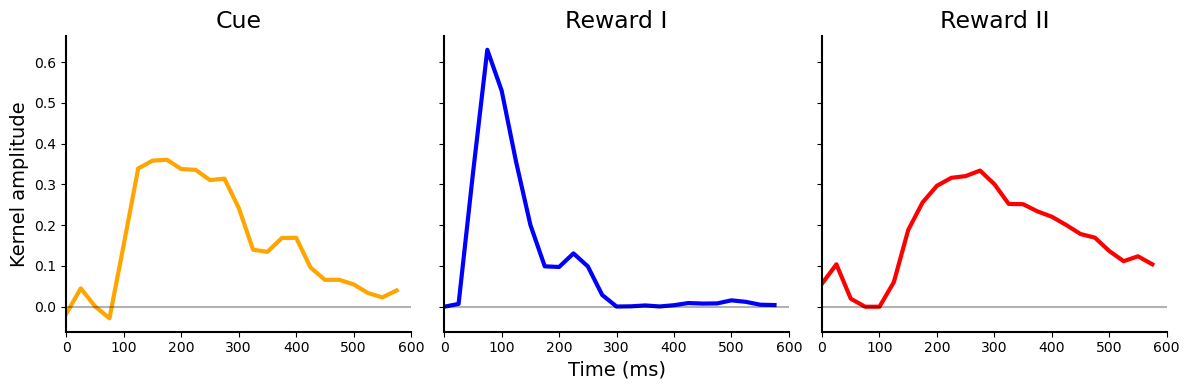

In [10]:
import matplotlib.pyplot as plt
import numpy as np

time = np.arange(H_np.shape[2]) * 25  # ms

#create the 1 by 3 subplot
fig, axes = plt.subplots(1, 3, figsize=(12,4), sharey=True)

labels = ["Cue", "Reward I", "Reward II"]
colors = ["orange", "blue", "red"]

# reorder kernels if necessary
kernels = [H_np[0,0], H_np[1,0], H_np[2,0]]

#plot the 3 kernels as 3 subplots
for i in range(3):
    axes[i].plot(time, kernels[i], color=colors[i], linewidth=3)
    axes[i].set_title(labels[i], fontsize = 17)
    axes[i].set_xlim(0,600)

    #remove borders on top and right side of graph to match the style of the paper
    axes[i].spines['top'].set_visible(False) 
    axes[i].spines['right'].set_visible(False)
    #make axes lines bolder
    axes[i].spines['left'].set_linewidth(1.5)
    axes[i].spines['bottom'].set_linewidth(1.5)
    axes[i].axhline(y=0, color = 'black', linestyle='-', alpha = 0.3) #horizontal line at kernel amplitude = 0

axes[0].set_ylabel("Kernel amplitude", fontsize = 14)
axes[1].set_xlabel("Time (ms)", fontsize = 14)

#plt.suptitle("Learned DUNL kernels", fontsize = 15)
plt.tight_layout()
plt.show()

### Figure 2D top Interpretation
Like in Tolooshams et al., DUNL learned 3 event-related kernels for the spiking data. Graphing the kernels showed that we successfully reproduced the results of their experiment. Figure 1 shows our replication of the figure. The kernels indicate the neuronal responses over time to distinct events, which were learned from the neural activity and the reward timing. 
* The Cue kernel corresponds to the neural activity during an odor cue which came before a reward was delivered.
* The Reward 1 kernel is for salience and is related to whether the reward was expected or unexpected.
* The Reward II kernel captures activity relating value of the reward, meaning it is correlated with the size of the reward (Tolooshams et al.).

One difference in our replication is that ours includes spikes at the beginning of each kernel. Tolooshams et al. noted that these initial spikes, which are salience-related, were removed from their window of analysis to improve how the size of the reward was represented. 
 


## Recreation of Figure 2D bottom

In [170]:
#recreate Figure 2D bottom: maximum code amplitude of each trial for one neuron.


#get codes for the kernals of 1 neuron.

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
model.to(device)
model.eval()

all_xhat = []

#use the data of the 1 neuron that was loaded into the variable data at the top of the notebook
# the data is contained in data['y']
y = data['y'].to(device) #shape is [trials, neurons, time]
print(y.shape)
print(data['type'].shape)

a = data['a'].to(device)

with torch.no_grad():
    xhat, a_est = model.encode(y,a, None)
xhat = xhat.cpu() 
print(xhat.shape)#xhat is shape 150,3,101. It contains 150 trials, the codes for the 3 kernels, 101 time positions where events occur

#extract codes for maximum amplitude of each trial for each kernel
#note: dunl does not guarantee continuity of order of kernels so through visualizing the codes, it was determined which codes 0 1 2 are which
cue_codes = xhat[:,1,:].max(dim=1).values #kernel 1 (cue) codes
salience_codes = xhat[:,2,:].max(dim=1).values #kernel 2 (reward I) codes
value_codes = xhat[:,0,:].max(dim=1).values #kernel 3 (reward II)codes

#convert them to numpy to plot
cue_codes = cue_codes.numpy()
salience_codes = salience_codes.numpy()
value_codes = value_codes.numpy()

#get reward size
reward_size = data['type']
print(reward_size.min(), reward_size.max()) #values 1-7


torch.Size([150, 1, 124])
torch.Size([150])
torch.Size([150, 3, 101])
tensor(1.) tensor(7.)


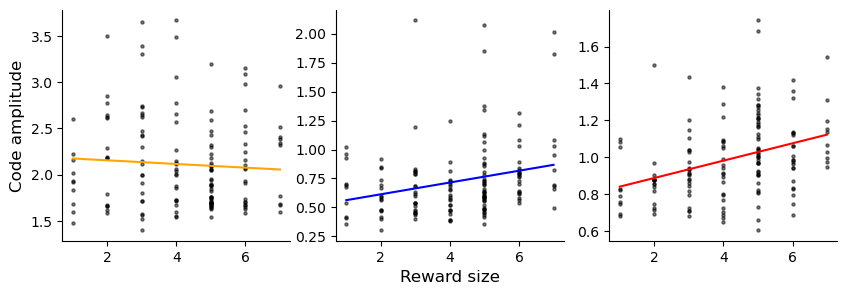

In [188]:
#regression line

#max code amplitude for each reward size
fig, axes = plt.subplots(1,3, figsize = (10,3), sharex = True)
colors = ['orange', 'blue', 'red']
codes = [cue_codes, salience_codes, value_codes]
for i in range(3):
    
    #scatter plots of code amplitudes
    axes[i].scatter(reward_size, codes[i], color='black', s=5, alpha=0.5)
    
    #regression lines for each plot
    coef = np.polyfit(reward_size, codes[i], 1)
    x = np.linspace(min(reward_size), max(reward_size),100)
    y = coef[0]*x + coef[1]
    axes[i].plot(x,y,color= colors[i])

 #remove borders on top and right side of graph to match the style of the paper
    axes[i].spines['top'].set_visible(False) 
    axes[i].spines['right'].set_visible(False)
    
axes[1].set_xlabel("Reward size", fontsize = 12)
axes[0].set_ylabel("Code amplitude", fontsize = 12)

plt.show()

### Figure 2D bottom explanation
This figure visualizes the distribution of sparse codes across individual trials for one neuron. For one individual neuron, its sparse codes represent the patterns of timing and strength of neural responses. Each dot is the maximum code amplitude in one trial.

### Similarities and differences to Tolooshams et al. Figure 2D bottom
**Differences:**
The kernels and codes reproduced with DUNL vary in kernel shape and code amplitude. This would be expected for separate DUNL runs, since training is randomly initialized so representations can be learned slightly differentlty.

Additionally, in their paper, reward size was represented in units of μL (microliters). In the dataset, rewards were described in 7 categories of increasing size. That is why our axis is 1-7 instead of up to 20 μL.

Finally, in their plot, they emphasized the distinction in the trends of code amplitude between expected (cue predicted) and unexpected (no cue) rewards for the purpose of their analysis. For our purposes of recreating DUNL's learned kernels and visualizing the activation of those kernels, we did not seek to further specify trials into expected and unexpected trial types.

**Similarities:**
The important result of the reproduction is the slopes. The slopes describe the trends in code amplitude as reward size increases. Our reproduction provides similar slopes to their paper. As reward size increases, cue code amplitude has a slight negative slope. Salience code amplitude and value code amplitude both have positive slopes.